**Iris Flower Classification Project**
**Project Overview**

This project uses machine learning to classify Iris flowers into three species  based on their physical measurements. The project demonstrates the complete machine learning workflow including data exploration, preprocessing, model training, evaluation, and interpretation.

**Objectives**

**The main objectives of this project are:**

To explore the Iris dataset
To clean and prepare the data
To perform exploratory data analysis (EDA)
To train a classification model
To evaluate model performance
To understand which features influence predictions most

**Step 1: Import Required Libraries**

This section imports all necessary Python libraries used for data analysis, visualization, and machine learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')


**Step 2: Load the Dataset**

The Iris dataset is loaded from Scikit-learn and converted into a Pandas DataFrame for easier analysis.

In [6]:
# Load from CSV file
df = pd.read_csv(r"C:\Users\Victor\Desktop\codealpha\archive (2)\Iris.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())

Dataset shape: (150, 6)

First 5 rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1)

***Step 3: Data Cleaning***

Ensure data quality before model training.

In [8]:
print("\nMissing values per column:")
print(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")
df_clean = df.drop_duplicates()
print(f"Shape after removing duplicates: {df_clean.shape}")

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

print("\nOutliers detected:")
# Get numeric columns only (exclude ID and Species columns)
numeric_columns = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Remove ID column if it exists
if 'Id' in numeric_columns:
    numeric_columns.remove('Id')
# Remove Species column (target variable)
if 'Species' in numeric_columns:
    numeric_columns.remove('Species')

for feature in numeric_columns:
    outliers = detect_outliers_iqr(df_clean, feature)
    print(f"{feature}: {len(outliers)} outliers")

print("\nData types:")
print(df_clean.dtypes)


Missing values per column:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Duplicate rows: 0
Shape after removing duplicates: (150, 6)

Outliers detected:
SepalLengthCm: 0 outliers
SepalWidthCm: 4 outliers
PetalLengthCm: 0 outliers
PetalWidthCm: 0 outliers

Data types:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object


**Step 4: Exploratory Data Analysis (EDA)**

Understand patterns, distributions, and relationships in the dataset.

Columns in your CSV: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species', 'species_name', 'species']
EXPLORATORY DATA ANALYSIS

Class Distribution:
species_name
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


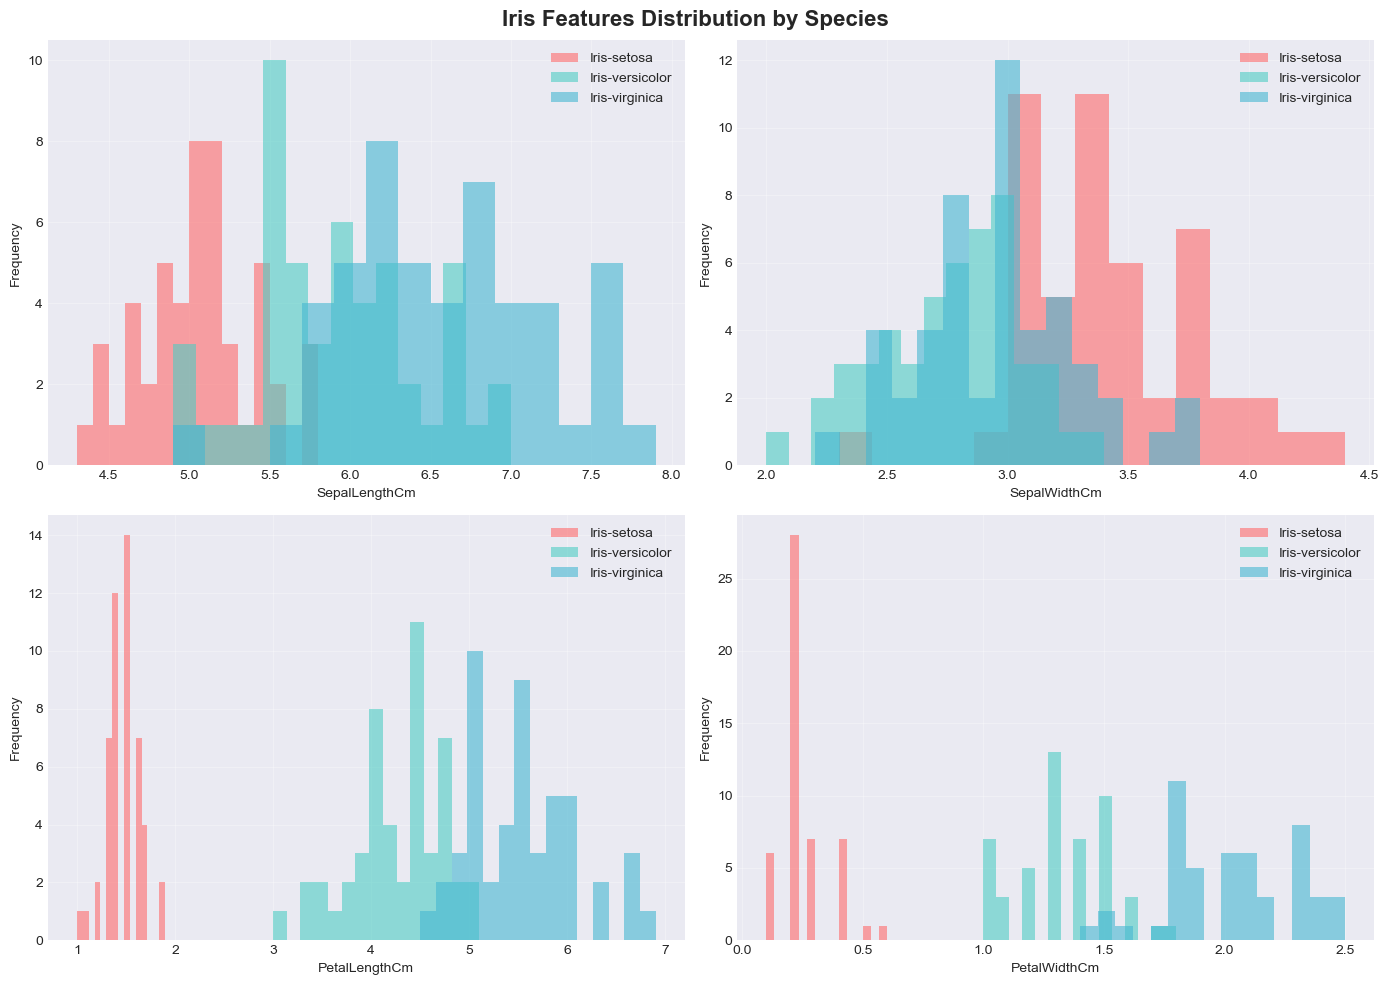

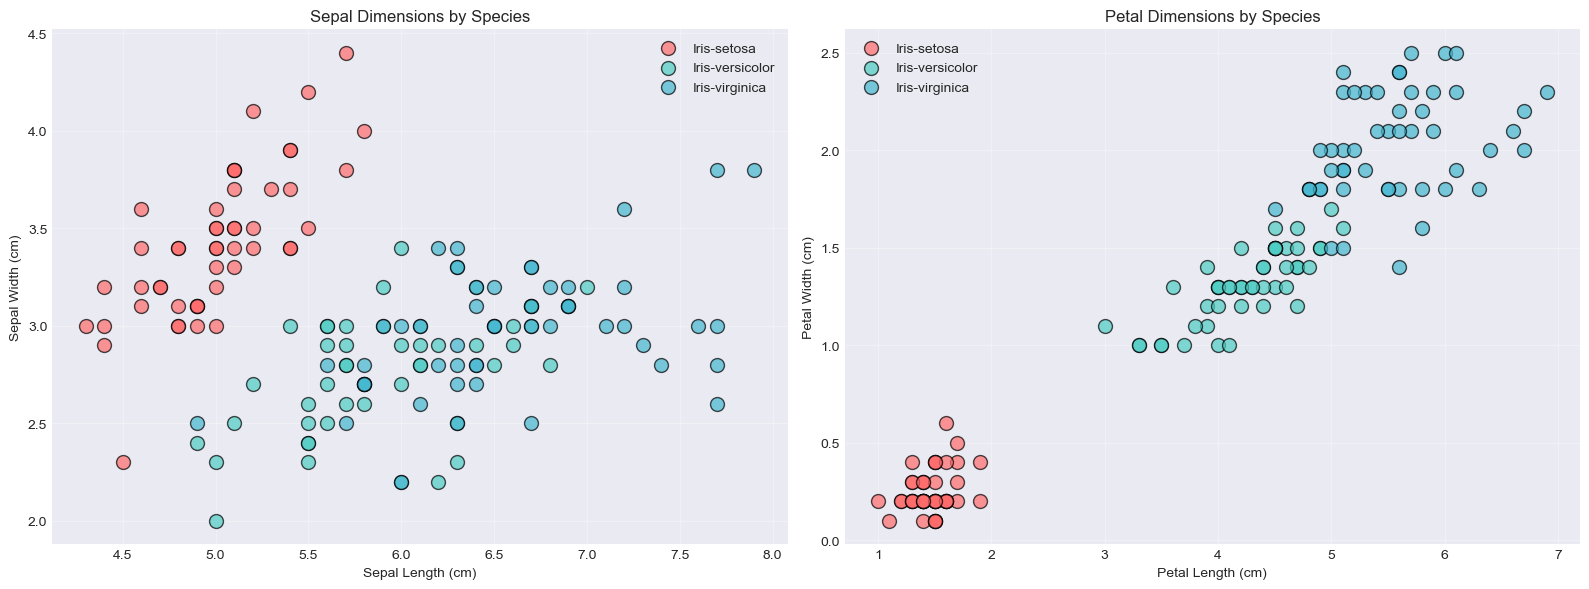

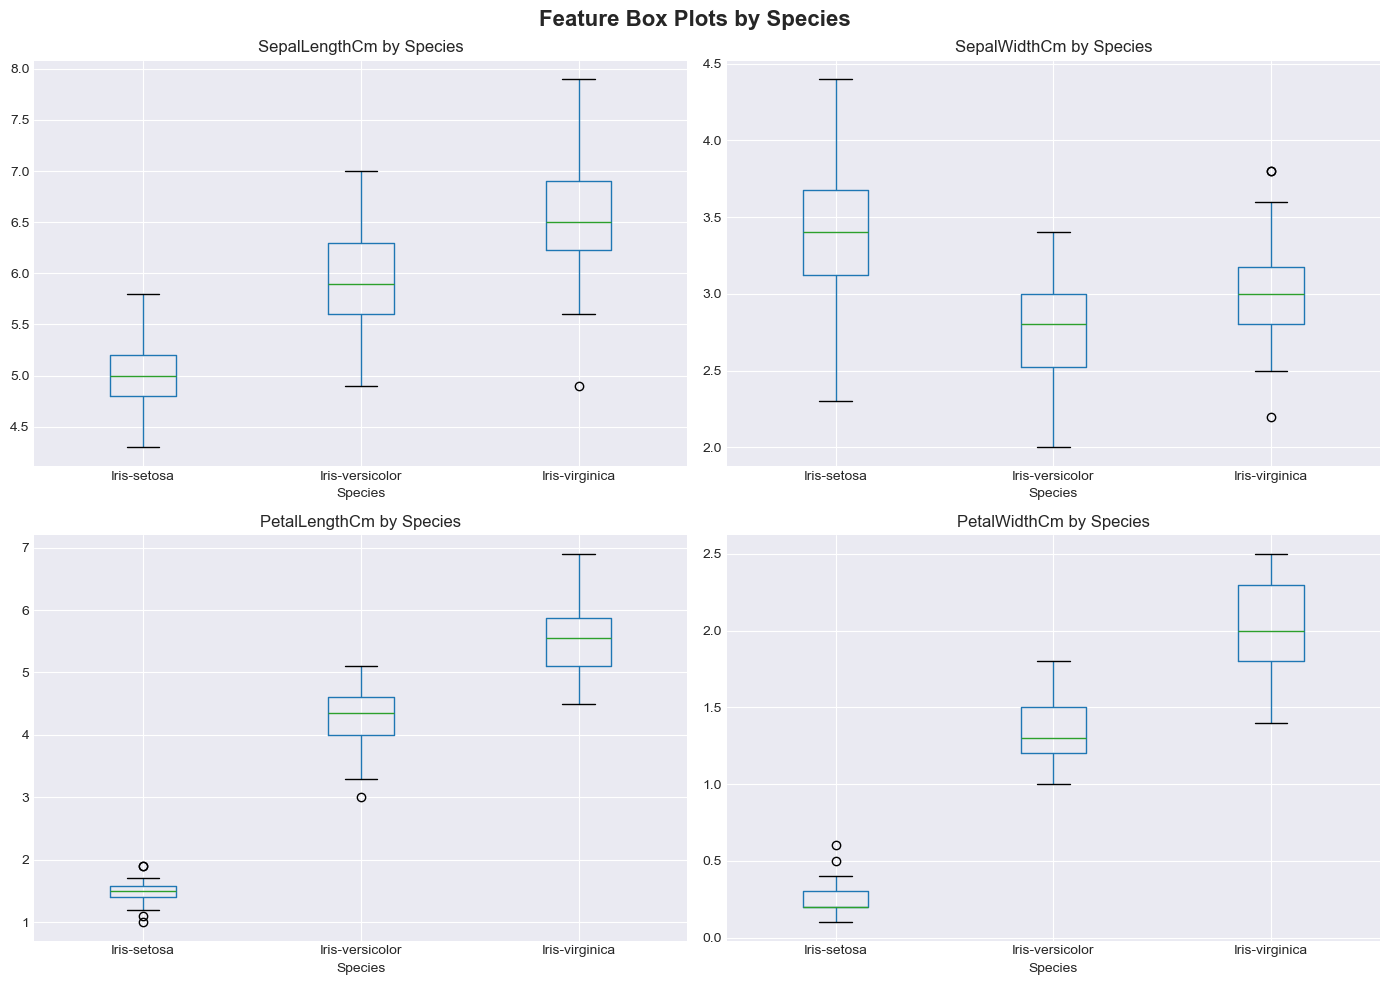

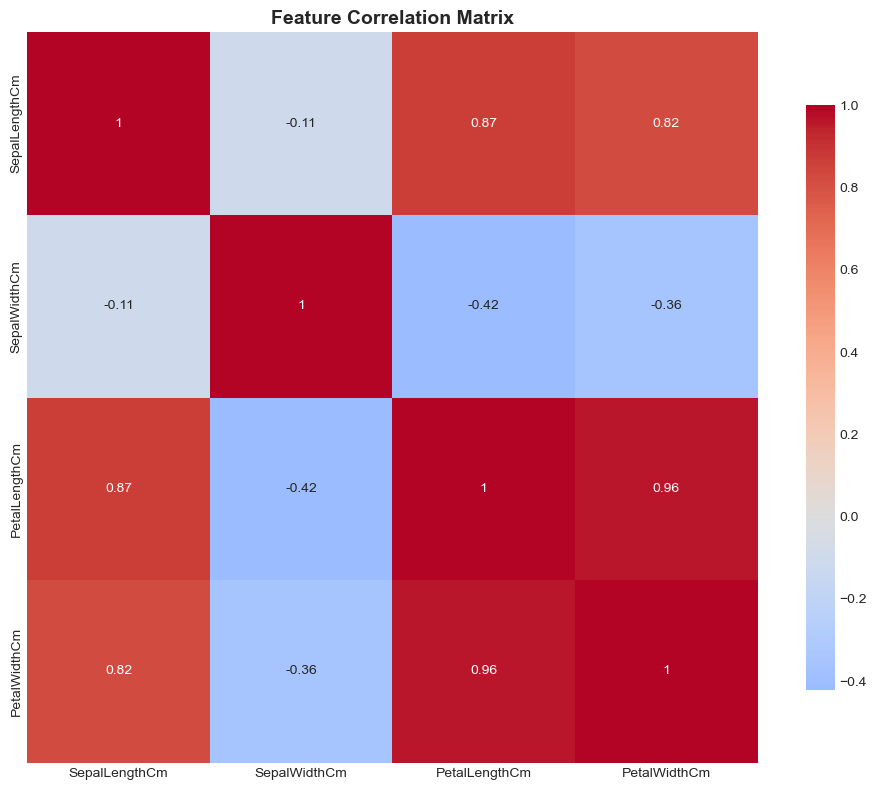


Mean values by species:
                 SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
species_name                                                             
Iris-setosa              5.006         3.418          1.464         0.244
Iris-versicolor          5.936         2.770          4.260         1.326
Iris-virginica           6.588         2.974          5.552         2.026

Standard deviation by species:
                 SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
species_name                                                             
Iris-setosa           0.352490      0.381024       0.173511      0.107210
Iris-versicolor       0.516171      0.313798       0.469911      0.197753
Iris-virginica        0.635880      0.322497       0.551895      0.274650

Correlation with species target:
SepalLengthCm: 0.7826
SepalWidthCm: -0.4194
PetalLengthCm: 0.9490
PetalWidthCm: 0.9565


In [11]:
# Check what columns exist
print("Columns in your CSV:", df.columns.tolist())

# Create species_name column from Species column
if 'Species' in df.columns:
    df['species_name'] = df['Species']
elif 'species' in df.columns:
    df['species_name'] = df['species']

# Create numeric species column for correlations
species_map = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2,
               'setosa': 0, 'versicolor': 1, 'virginica': 2}
df['species'] = df['species_name'].map(species_map)

# Remove duplicates
df_clean = df.drop_duplicates()

# Get feature columns 
feature_cols = [col for col in df_clean.columns 
                if col not in ['Id', 'Species', 'species_name', 'species']]
feature_cols = df_clean[feature_cols].select_dtypes(include=['float64', 'int64']).columns.tolist()


print("EXPLORATORY DATA ANALYSIS")


# Class distribution
print("\nClass Distribution:")
print(df_clean['species_name'].value_counts())

# Feature distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Iris Features Distribution by Species', fontsize=16, fontweight='bold')
colors = {'setosa': '#FF6B6B', 'versicolor': '#4ECDC4', 'virginica': '#45B7D1',
          'Iris-setosa': '#FF6B6B', 'Iris-versicolor': '#4ECDC4', 'Iris-virginica': '#45B7D1'}

for idx, feature in enumerate(feature_cols):
    ax = axes[idx // 2, idx % 2]
    for species in df_clean['species_name'].unique():
        subset = df_clean[df_clean['species_name'] == species]
        ax.hist(subset[feature], alpha=0.6, label=species, color=colors.get(species, 'gray'), bins=15)
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('iris_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax1, ax2 = axes

# Find sepal and petal columns dynamically
sepal_length = [c for c in feature_cols if 'sepal' in c.lower() and 'length' in c.lower()][0]
sepal_width = [c for c in feature_cols if 'sepal' in c.lower() and 'width' in c.lower()][0]
petal_length = [c for c in feature_cols if 'petal' in c.lower() and 'length' in c.lower()][0]
petal_width = [c for c in feature_cols if 'petal' in c.lower() and 'width' in c.lower()][0]

for species in df_clean['species_name'].unique():
    subset = df_clean[df_clean['species_name'] == species]
    ax1.scatter(subset[sepal_length], subset[sepal_width], 
                c=colors.get(species, 'gray'), label=species, s=100, alpha=0.7, edgecolors='black')
ax1.set_xlabel('Sepal Length (cm)')
ax1.set_ylabel('Sepal Width (cm)')
ax1.set_title('Sepal Dimensions by Species')
ax1.legend()
ax1.grid(True, alpha=0.3)

for species in df_clean['species_name'].unique():
    subset = df_clean[df_clean['species_name'] == species]
    ax2.scatter(subset[petal_length], subset[petal_width], 
                c=colors.get(species, 'gray'), label=species, s=100, alpha=0.7, edgecolors='black')
ax2.set_xlabel('Petal Length (cm)')
ax2.set_ylabel('Petal Width (cm)')
ax2.set_title('Petal Dimensions by Species')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('iris_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# Box plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, feature in enumerate(feature_cols):
    ax = axes[idx // 2, idx % 2]
    df_clean.boxplot(column=feature, by='species_name', ax=ax)
    ax.set_title(f'{feature} by Species')
    ax.set_xlabel('Species')
fig.suptitle('Feature Box Plots by Species', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('iris_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 8))
corr_matrix = df_clean[feature_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('iris_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMean values by species:")
print(df_clean.groupby('species_name')[feature_cols].mean())
print("\nStandard deviation by species:")
print(df_clean.groupby('species_name')[feature_cols].std())

print("\nCorrelation with species target:")
for feature in feature_cols:
    correlation = df_clean[feature].corr(df_clean['species'])
    print(f"{feature}: {correlation:.4f}")

**Step 5: Machine Learning Model**

Train a model to classify Iris species.

In [21]:
# Features (X) and target (y)
X = df_clean[feature_cols]
y = df_clean['species_name']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (150, 4)
Target shape: (150,)


In [22]:
# Split dataset (80% train, 20% test)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
# Build model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

# Train model
rf_model.fit(X_train_scaled, y_train)

print("Model training complete")

Model training complete


In [25]:
y_pred = rf_model.predict(X_test_scaled)


Model Accuracy: 0.9
Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



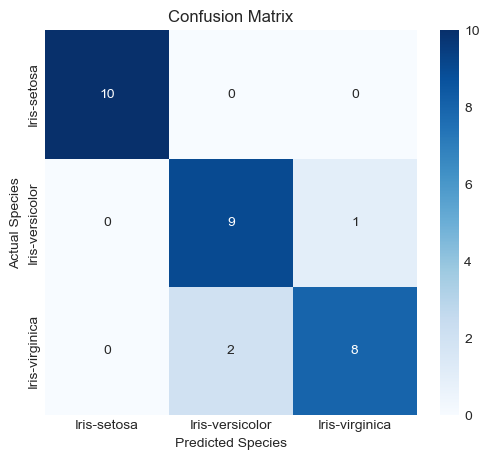

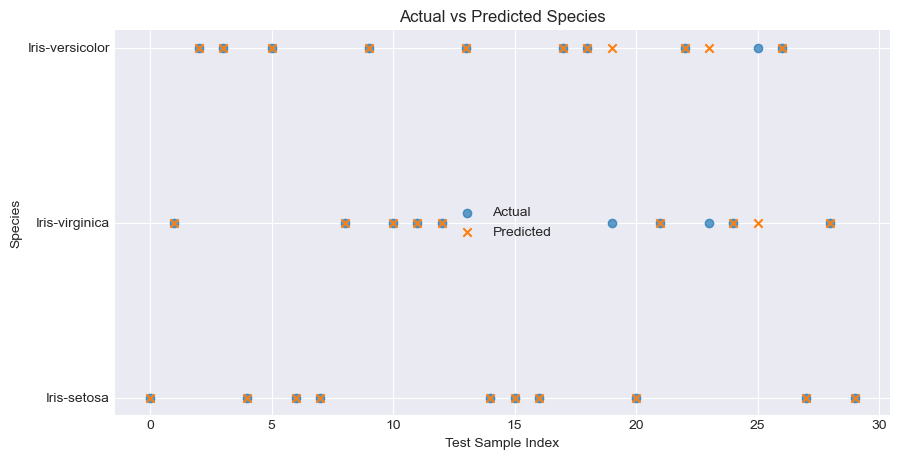

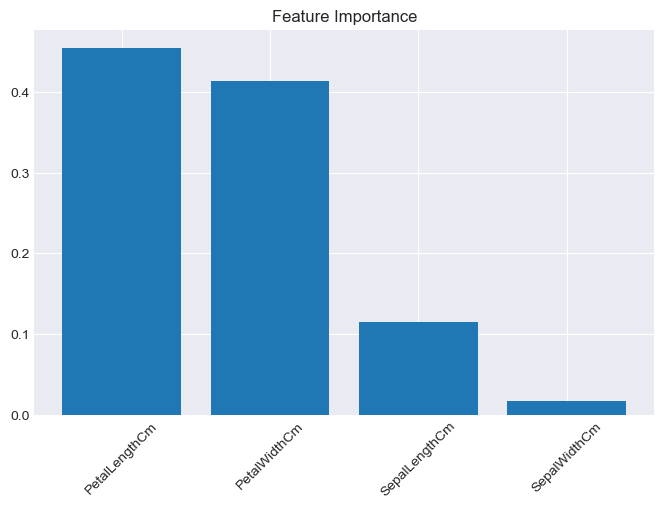

         Feature  Importance
2  PetalLengthCm    0.454024
3   PetalWidthCm    0.413976
0  SepalLengthCm    0.115216
1   SepalWidthCm    0.016783


In [26]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Classification Report:\n")

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.title("Confusion Matrix")

plt.show()
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

plt.figure(figsize=(10,5))

plt.scatter(
    range(len(results)),
    results['Actual'],
    label='Actual',
    alpha=0.7
)

plt.scatter(
    range(len(results)),
    results['Predicted'],
    label='Predicted',
    marker='x'
)

plt.legend()

plt.title("Actual vs Predicted Species")

plt.xlabel("Test Sample Index")

plt.ylabel("Species")

plt.show()
importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.title("Feature Importance")

plt.xticks(rotation=45)

plt.show()

print(importance_df)

**Predicted vs Actual Comparison Chart**

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

plt.figure(figsize=(12,5))

plt.plot(
    results['Actual'].values,
    label="Actual",
    marker='o'
)

plt.plot(
    results['Predicted'].values,
    label="Predicted",
    marker='x'
)

plt.title("Actual vs Predicted Species Comparison")

plt.xlabel("Test Samples")

plt.ylabel("Species")

plt.legend()

plt.grid(True)

plt.show()

**Feature Importance Plot**

C:\Users\Victor\AppData\Local\Temp\ipykernel_17508\2952805658.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


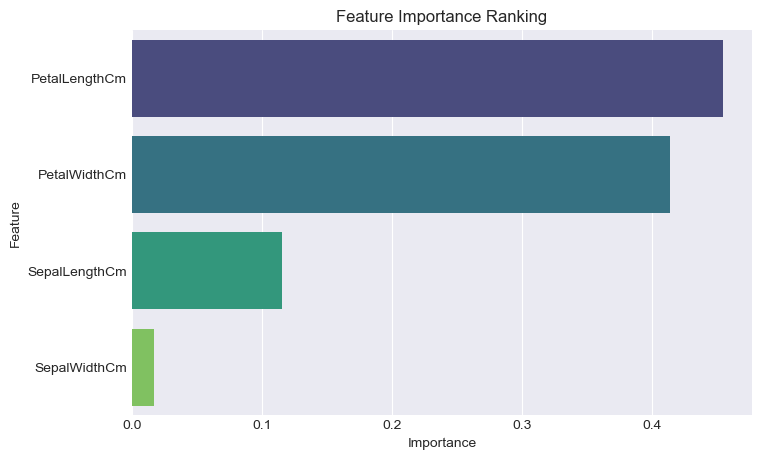

In [31]:
importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature':feature_cols,
    'Importance':importance
}).sort_values(by='Importance',ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df,
    palette='viridis'
)

plt.title("Feature Importance Ranking")

plt.show()

**Class Prediction Distribution**

C:\Users\Victor\AppData\Local\Temp\ipykernel_17508\552549188.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


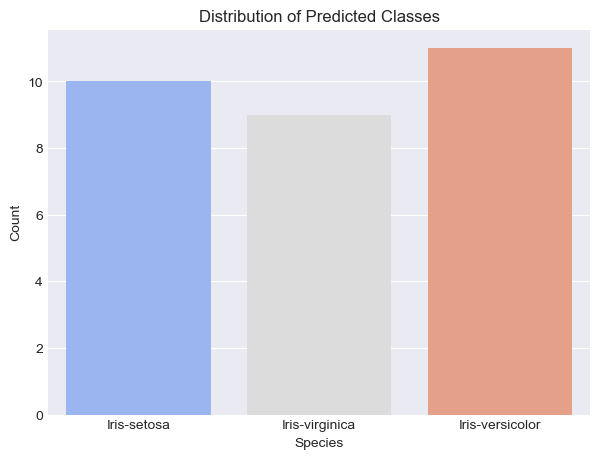

In [32]:
plt.figure(figsize=(7,5))

sns.countplot(
    x=y_pred,
    palette="coolwarm"
)

plt.title("Distribution of Predicted Classes")

plt.xlabel("Species")

plt.ylabel("Count")

plt.show()

**Correct vs Incorrect Predictions**

C:\Users\Victor\AppData\Local\Temp\ipykernel_17508\1073957749.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


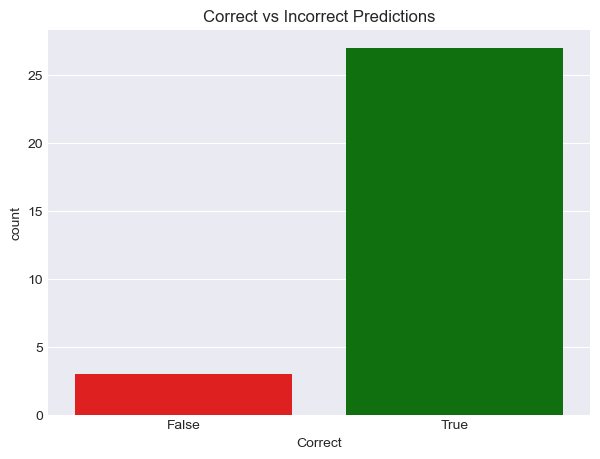

Correct
True     27
False     3
Name: count, dtype: int64


In [33]:
results['Correct'] = results['Actual'] == results['Predicted']

plt.figure(figsize=(7,5))

sns.countplot(
    x='Correct',
    data=results,
    palette=['red','green']
)

plt.title("Correct vs Incorrect Predictions")

plt.show()

print(results['Correct'].value_counts())